In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data(file_name: str) -> pd.DataFrame:
    """
    Loads the raw SEN Excel file.

    Returns:
        pandas DataFrame containing the raw SEN data
    """
    return pd.read_excel(file_name)


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans and prepares the SEN dataset.

    - parses the Data column as datetime
    - converts MW columns to numeric values
    - removes rows with invalid dates
    - removes duplicates
    - sorts observations chronologically
    """

    df = df.copy()

    df["Data"] = pd.to_datetime(
        df["Data"],
        dayfirst=True,
        errors="coerce"
    )

    numeric_columns = df.columns.drop("Data")

    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df.dropna(subset=["Data"])
    df = df.drop_duplicates()
    df = df.sort_values("Data").reset_index(drop=True)

    return df

def save_data(df: pd.DataFrame, file_name: str) -> None:
    """
    Saves the cleaned SEN dataset as CSV.
    """
    df.to_csv(file_name, index=False)

In [ ]:
raw_df = load_data("../data/raw/Grafic_SEN_2025.xlsx")

df = clean_data(raw_df)

df["Ora"] = df["Data"].dt.hour

save_data(
    df,
    "../data/processed/sen_2025_clean.csv"
)

c:\Users\albaa\Desktop\my stuff\Lucru\MBK Energy\mbk-sen-eda\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [20]:
# Q1 Cum arată sarcina reziduală (consum total − eolian − solar) pe parcursul zilei și cât trebuie completat de producția convențională?

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Sarcina ramasa dupa fiecare tip de productie
df["RezidualaSolar[MW]"] = (
    df["Consum[MW]"]
    - df["Foto[MW]"]
)

df["RezidualaEolian[MW]"] = (
    df["Consum[MW]"]
    - df["Eolian[MW]"]
)

df["SarcinaReziduala[MW]"] = (
    df["Consum[MW]"]
    - df["Eolian[MW]"]
    - df["Foto[MW]"]
)

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Profilul mediu pe fiecare ora a zilei
hourly_profile = df.groupby("Ora")[
    ["Consum[MW]", "SarcinaReziduala[MW]", "Eolian[MW]", "Foto[MW]"]
].mean()

# Ponderea din consum care ramane de acoperit dupa eolian si solar
hourly_profile["PondereReziduala[%]"] = (
    hourly_profile["SarcinaReziduala[MW]"]
    / hourly_profile["Consum[MW]"] * 100
)

hourly_profile["ContributieEolianSolar[%]"] = (
    100 - hourly_profile["PondereReziduala[%]"]
)

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Indicatorii generali pentru 2025

consumption_mean = df["Consum[MW]"].mean()
residual_mean = df["SarcinaReziduala[MW]"].mean()

# Raportul dintre sarcina reziduala totala si consumul total
residual_share = (
    df["SarcinaReziduala[MW]"].sum()
    / df["Consum[MW]"].sum() * 100
)

renewable_share = 100 - residual_share


print(f"Consum mediu: {consumption_mean:.0f} MW")
print(f"Sarcina reziduala medie: {residual_mean:.0f} MW")
print(f"Pondere reziduala: {residual_share:.1f}%")
print(f"Contributie eolian + solar: {renewable_share:.1f}%")

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Momente relevante ale profilului zilnic

midday_profile = hourly_profile.loc[11:15]
evening_profile = hourly_profile.loc[17:21]

midday_min_hour = midday_profile["SarcinaReziduala[MW]"].idxmin()
midday_min_value = midday_profile["SarcinaReziduala[MW]"].min()

evening_max_hour = evening_profile["SarcinaReziduala[MW]"].idxmax()
evening_max_value = evening_profile["SarcinaReziduala[MW]"].max()

print(
    f"Minim mediu al sarcinii reziduale la pranz: "
    f"{midday_min_value:.0f} MW, la ora {midday_min_hour}"
)

print(
    f"Maxim mediu al sarcinii reziduale seara: "
    f"{evening_max_value:.0f} MW, la ora {evening_max_hour}"
)

Consum mediu: 6113 MW
Sarcina reziduala medie: 5124 MW
Pondere reziduala: 83.8%
Contributie eolian + solar: 16.2%
Minim mediu al sarcinii reziduale la pranz: 4174 MW, la ora 12
Maxim mediu al sarcinii reziduale seara: 6493 MW, la ora 20


Cea mai mare crestere medie apare in jurul orei 17: 114 MW / ~10 min
Cea mai mare scadere medie apare in jurul orei 22: -101 MW / ~10 min

Cea mai mare crestere observata in 2025: 1394 MW / ~10 min, la 2025-07-25 17:49:04
Cea mai mare scadere observata in 2025: -1218 MW / ~10 min, la 2025-12-25 17:13:14

Top 10 ramp-up:
                     Data  Ora  Rampa[MW]
29835 2025-07-25 17:49:04   17     1394.0
51848 2025-12-25 17:23:41   17     1370.0
24908 2025-06-21 22:22:54   22      964.0
50788 2025-12-18 08:05:32    8      595.0
49014 2025-12-05 23:48:31   23      521.0
10747 2025-03-16 08:19:38    8      505.0
39166 2025-09-28 15:34:32   15      483.0
32856 2025-08-15 18:06:09   18      479.0
26050 2025-06-29 19:07:19   19      477.0
32303 2025-08-11 18:07:08   18      475.0

Top 10 ramp-down:
                     Data  Ora  Rampa[MW]
51847 2025-12-25 17:13:14   17    -1218.0
29834 2025-07-25 17:39:12   17    -1169.0
24907 2025-06-21 22:13:02   22    -1061.0
49016 2025-12-06 00:08:23    

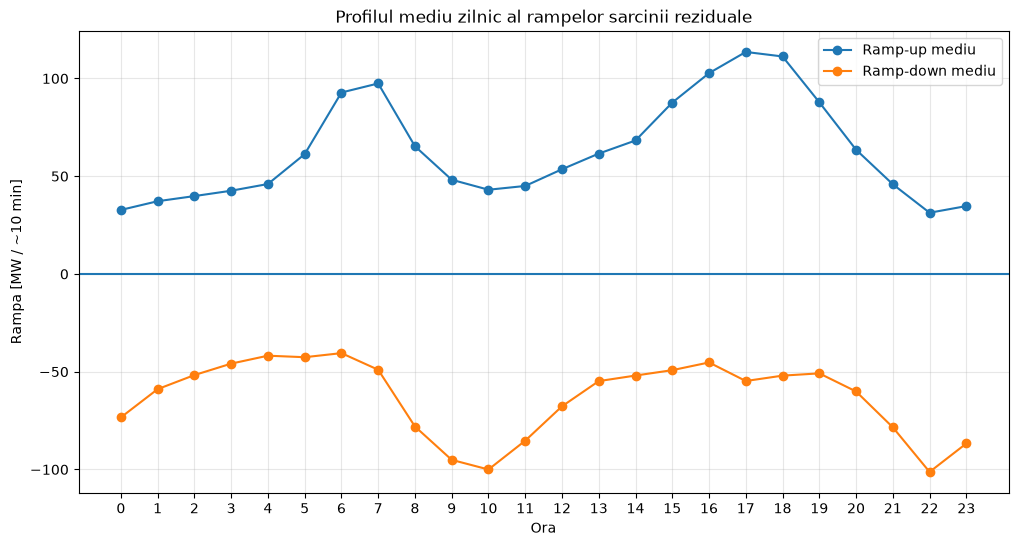

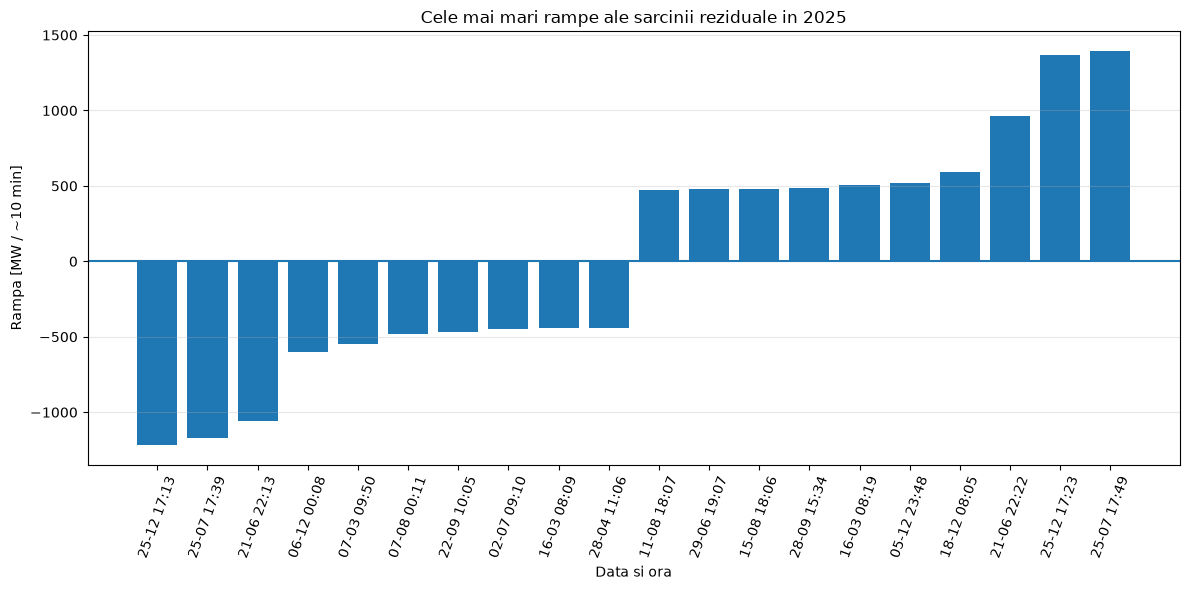

In [ ]:
# Q2 - Care sunt cele mai mari rampe și la ce ore apar?

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Calculam intervalul dintre observatii, in minute
df["IntervalMinute"] = (
    df["Data"].diff().dt.total_seconds() / 60
)

# Rampa = modificarea sarcinii reziduale fata de observatia anterioara
df["Rampa[MW]"] = (
    df["SarcinaReziduala[MW]"]
    - df["SarcinaReziduala[MW]"].shift(1)
)

# Pastram doar observatiile aflate la aproximativ 10 minute distanta,
# pentru ca rampele sa fie comparabile
df_rampe = df[
    (df["IntervalMinute"] >= 9)
    & (df["IntervalMinute"] <= 11)
].copy()


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Profilul mediu al rampelor pe fiecare ora a zilei

# Separarea este necesara pentru ca ramp-up si ramp-down
# sa nu se anuleze atunci cand calculam media
ramp_up = df_rampe[df_rampe["Rampa[MW]"] > 0]
ramp_down = df_rampe[df_rampe["Rampa[MW]"] < 0]

hourly_ramp_up = (
    ramp_up.groupby("Ora")["Rampa[MW]"].mean()
)

hourly_ramp_down = (
    ramp_down.groupby("Ora")["Rampa[MW]"].mean()
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Momente relevante ale profilului zilnic

# Ora cu cea mai puternica crestere medie
max_avg_ramp_up_hour = hourly_ramp_up.idxmax()
max_avg_ramp_up_value = hourly_ramp_up.max()

# Ora cu cea mai puternica scadere medie
max_avg_ramp_down_hour = hourly_ramp_down.idxmin()
max_avg_ramp_down_value = hourly_ramp_down.min()

print(
    f"Cea mai mare crestere medie apare in jurul orei "
    f"{max_avg_ramp_up_hour}: "
    f"{max_avg_ramp_up_value:.0f} MW / ~10 min"
)

print(
    f"Cea mai mare scadere medie apare in jurul orei "
    f"{max_avg_ramp_down_hour}: "
    f"{max_avg_ramp_down_value:.0f} MW / ~10 min"
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Cele mai extreme rampe observate in 2025

largest_ramp_up = df_rampe.nlargest(10, "Rampa[MW]")
largest_ramp_down = df_rampe.nsmallest(10, "Rampa[MW]")

# Cea mai mare crestere din intregul an
max_ramp_up = largest_ramp_up.iloc[0]

# Cea mai mare scadere din intregul an
max_ramp_down = largest_ramp_down.iloc[0]

print()

print(
    f"Cea mai mare crestere observata in 2025: "
    f"{max_ramp_up['Rampa[MW]']:.0f} MW / ~10 min, "
    f"la {max_ramp_up['Data']}"
)

print(
    f"Cea mai mare scadere observata in 2025: "
    f"{max_ramp_down['Rampa[MW]']:.0f} MW / ~10 min, "
    f"la {max_ramp_down['Data']}"
)

print()

print("Top 10 ramp-up:")
print(
    largest_ramp_up[[
        "Data",
        "Ora",
        "Rampa[MW]"
    ]]
)

print()

print("Top 10 ramp-down:")
print(
    largest_ramp_down[[
        "Data",
        "Ora",
        "Rampa[MW]"
    ]]
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Grafic 1 - Profilul mediu zilnic al rampelor

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_ramp_up.index,
    hourly_ramp_up.values,
    marker="o",
    label="Ramp-up mediu"
)

plt.plot(
    hourly_ramp_down.index,
    hourly_ramp_down.values,
    marker="o",
    label="Ramp-down mediu"
)

plt.axhline(0)

plt.xlabel("Ora")
plt.ylabel("Rampa [MW / ~10 min]")
plt.title("Profilul mediu zilnic al rampelor sarcinii reziduale")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Grafic 2 - Cele mai extreme rampe observate in 2025

top_ramps = pd.concat([
    largest_ramp_down,
    largest_ramp_up
]).sort_values("Rampa[MW]")

plt.figure(figsize=(12, 6))

plt.bar(
    top_ramps["Data"].dt.strftime("%d-%m %H:%M"),
    top_ramps["Rampa[MW]"]
)

plt.axhline(0)

plt.xlabel("Data si ora")
plt.ylabel("Rampa [MW / ~10 min]")
plt.title("Cele mai mari rampe ale sarcinii reziduale in 2025")

plt.xticks(rotation=70)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()


     Anotimp  Ora peak solar  Peak solar [MW]  Ora minim rezidual  \
0      Iarna              12       619.216418                  12   
1  Primavara              12      1016.889286                  13   
2       Vara              12      1374.012590                  12   
3     Toamna              12       933.192308                  12   

   Minim rezidual [MW]  Scadere dimineata-pranz [MW]  Ora maxim seara  \
0          5469.360075                   1071.834370               18   
1          3610.535390                   1626.214610               20   
2          3475.451439                   1515.389633               21   
3          4177.706960                   1403.548982               19   

   Maxim rezidual seara [MW]  Crestere pranz-seara [MW]  \
0                7205.098330                1735.738256   
1                6234.750896                2624.215506   
2                6466.397482                2990.946043   
3                6414.318681                2236.611

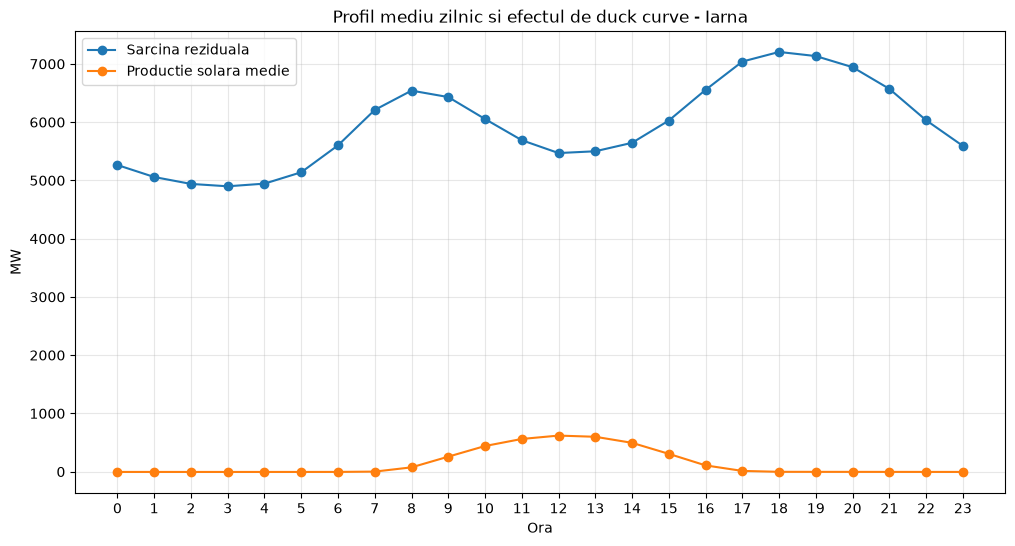

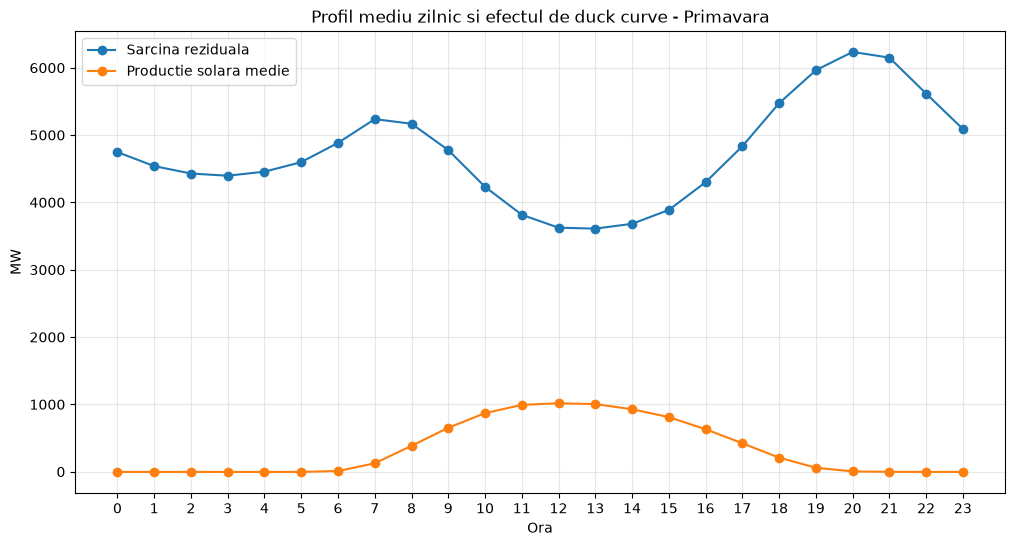

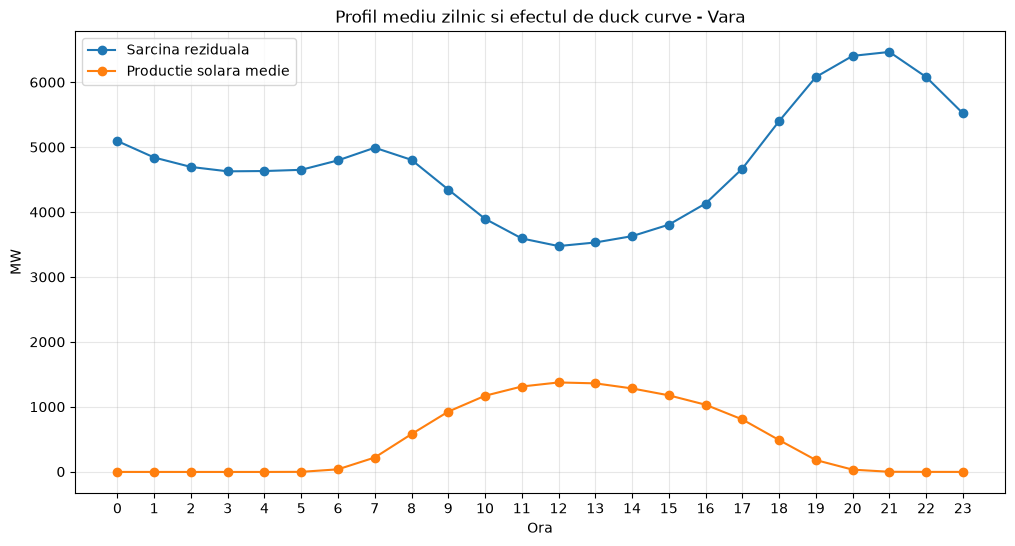

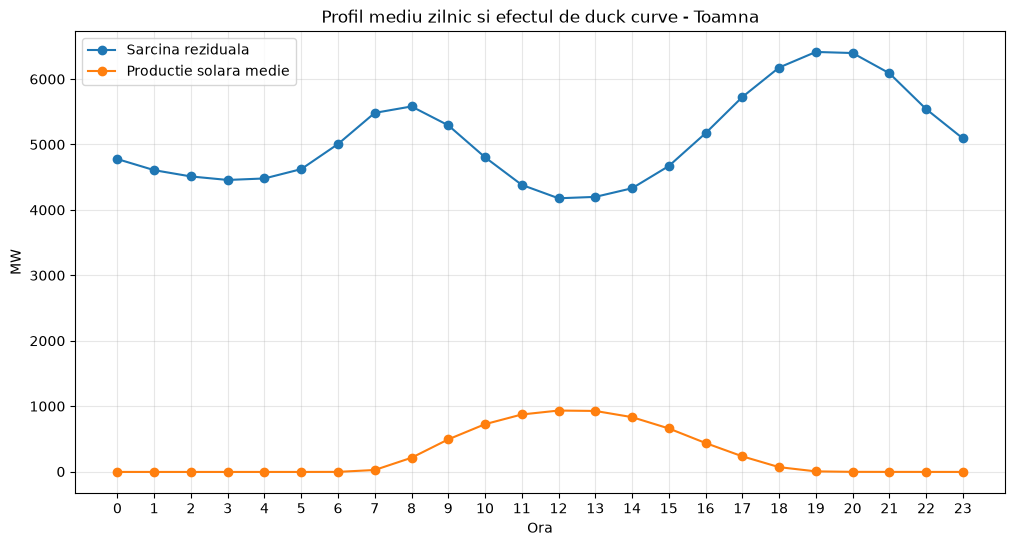

In [18]:
# Q3 - Exista momente cu "duck curve"
# (scadere la pranz asociata productiei solare si urcare rapida spre seara)?

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Impartirea datelor pe anotimpuri

df["Anotimp"] = df["Data"].dt.month.map({
    12: "Iarna",
    1: "Iarna",
    2: "Iarna",
    3: "Primavara",
    4: "Primavara",
    5: "Primavara",
    6: "Vara",
    7: "Vara",
    8: "Vara",
    9: "Toamna",
    10: "Toamna",
    11: "Toamna"
})

sezoane = [
    "Iarna",
    "Primavara",
    "Vara",
    "Toamna"
]


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Profilul mediu pe ore pentru fiecare anotimp

hourly_duck = df.groupby(
    ["Anotimp", "Ora"]
)[
    [
        "Consum[MW]",
        "Foto[MW]",
        "SarcinaReziduala[MW]"
    ]
].mean()


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Indicatorii relevanti pentru identificarea duck curve

duck_results = []

for sezon in sezoane:

    sezon_data = hourly_duck.loc[sezon]

    # Intervalele analizate
    morning_profile = sezon_data.loc[6:10]
    midday_profile = sezon_data.loc[11:15]
    evening_profile = sezon_data.loc[17:21]

    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Productia solara maxima

    solar_peak_hour = sezon_data["Foto[MW]"].idxmax()
    solar_peak_value = sezon_data["Foto[MW]"].max()


    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Minimul sarcinii reziduale la pranz

    midday_min_hour = (
        midday_profile["SarcinaReziduala[MW]"].idxmin()
    )

    midday_min_value = (
        midday_profile["SarcinaReziduala[MW]"].min()
    )


    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Nivelul ridicat al sarcinii reziduale dinainte de scaderea de la pranz

    morning_max_hour = (
        morning_profile["SarcinaReziduala[MW]"].idxmax()
    )

    morning_max_value = (
        morning_profile["SarcinaReziduala[MW]"].max()
    )

    midday_drop = (
        morning_max_value
        - midday_min_value
    )


    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Revenirea sarcinii reziduale spre seara

    evening_max_hour = (
        evening_profile["SarcinaReziduala[MW]"].idxmax()
    )

    evening_max_value = (
        evening_profile["SarcinaReziduala[MW]"].max()
    )

    evening_rise = (
        evening_max_value
        - midday_min_value
    )


    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Cea mai mare crestere medie intre doua ore consecutive spre seara

    evening_hourly_change = (
        sezon_data.loc[16:21, "SarcinaReziduala[MW]"].diff()
    )

    max_evening_rise_hour = (
        evening_hourly_change.idxmax()
    )

    max_evening_rise_value = (
        evening_hourly_change.max()
    )


    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Salvarea rezultatelor sezonului

    duck_results.append({
        "Anotimp": sezon,

        "Ora peak solar": solar_peak_hour,
        "Peak solar [MW]": solar_peak_value,

        "Ora minim rezidual": midday_min_hour,
        "Minim rezidual [MW]": midday_min_value,

        "Scadere dimineata-pranz [MW]": midday_drop,

        "Ora maxim seara": evening_max_hour,
        "Maxim rezidual seara [MW]": evening_max_value,

        "Crestere pranz-seara [MW]": evening_rise,

        "Ora crestere maxima seara": max_evening_rise_hour,
        "Crestere maxima orara [MW]": max_evening_rise_value
    })


# Transformam rezultatele intr-un DataFrame
duck_summary = pd.DataFrame(duck_results)

print(duck_summary)

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Grafice - profilul mediu zilnic pentru fiecare anotimp

for sezon in sezoane:

    sezon_data = hourly_duck.loc[sezon]

    plt.figure(figsize=(12, 6))

    # plt.plot(
    #     sezon_data.index,
    #     sezon_data["Consum[MW]"],
    #     marker="o",
    #     label="Consum mediu"
    # )

    plt.plot(
        sezon_data.index,
        sezon_data["SarcinaReziduala[MW]"],
        marker="o",
        label="Sarcina reziduala"
    )

    plt.plot(
        sezon_data.index,
        sezon_data["Foto[MW]"],
        marker="o",
        label="Productie solara medie"
    )

    plt.xlabel("Ora")
    plt.ylabel("MW")

    plt.title(
        f"Profil mediu zilnic si efectul de duck curve - {sezon}"
    )

    plt.xticks(range(24))
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

Diferenta medie productie - consum: -416 MW
Diferenta mediana productie - consum: -477 MW
Observatii cu productie sub consum: 70.9%
Observatii cu productie peste consum: 29.1%
Sold mediu: 415 MW
Eroare medie absoluta a balantei: 0.56 MW (0.009% din consumul mediu)

Cel mai mare deficit mediu apare in jurul orei 20: -1059 MW
Cel mai mare surplus mediu apare in jurul orei 12: 103 MW

Top 10 momente cu productie sub consum:
                    Data  Productie[MW]  Consum[MW]  \
8051 2025-02-25 18:44:27         5732.0      8685.0   
8049 2025-02-25 18:24:32         5551.0      8498.0   
1981 2025-01-14 17:52:34         5823.0      8735.0   
8052 2025-02-25 18:54:19         5687.0      8590.0   
1979 2025-01-14 17:32:35         5739.0      8610.0   
1982 2025-01-14 18:02:27         5906.0      8775.0   
8050 2025-02-25 18:34:30         5686.0      8551.0   
1990 2025-01-14 19:21:25         5833.0      8694.0   
1980 2025-01-14 17:42:26         5794.0      8649.0   
1978 2025-01-14 17:22:42 

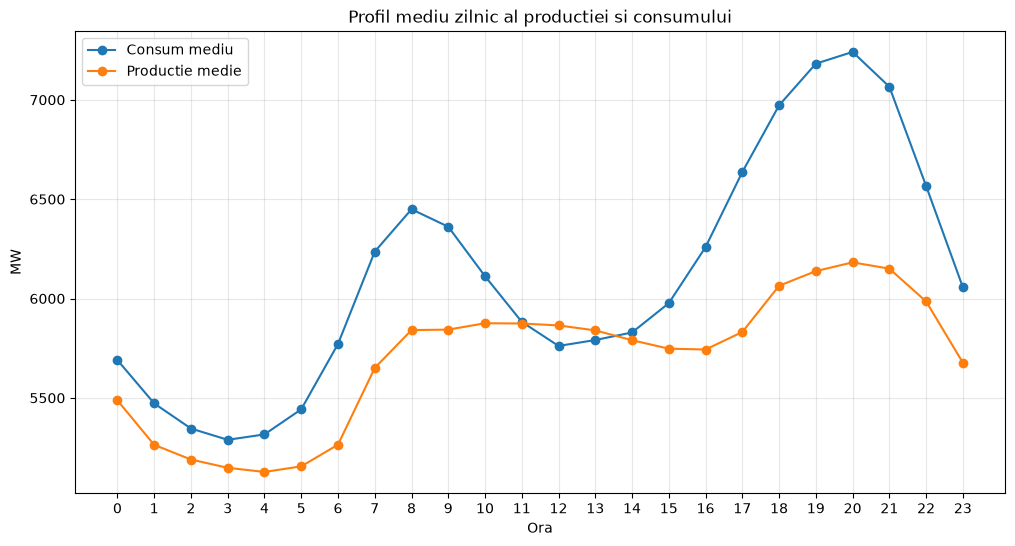

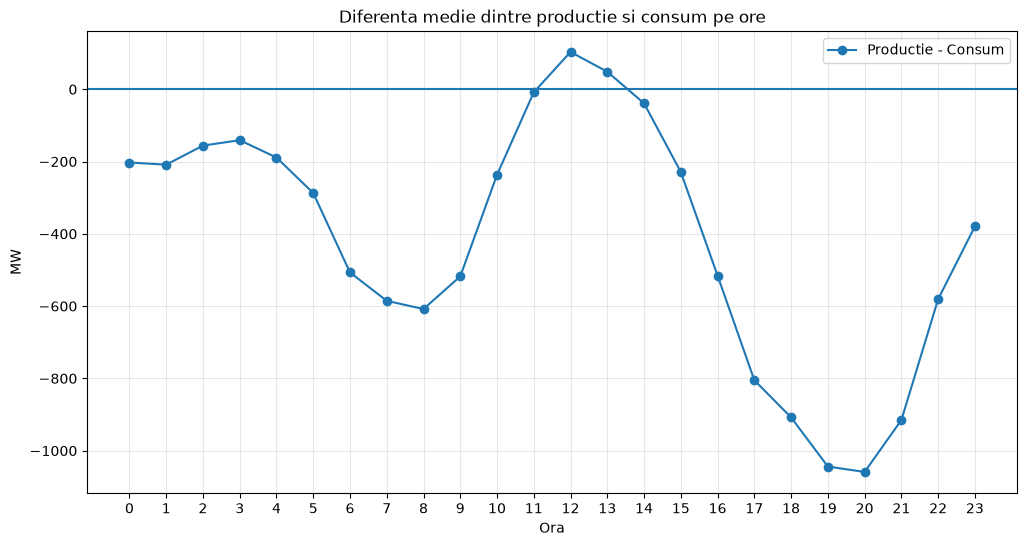

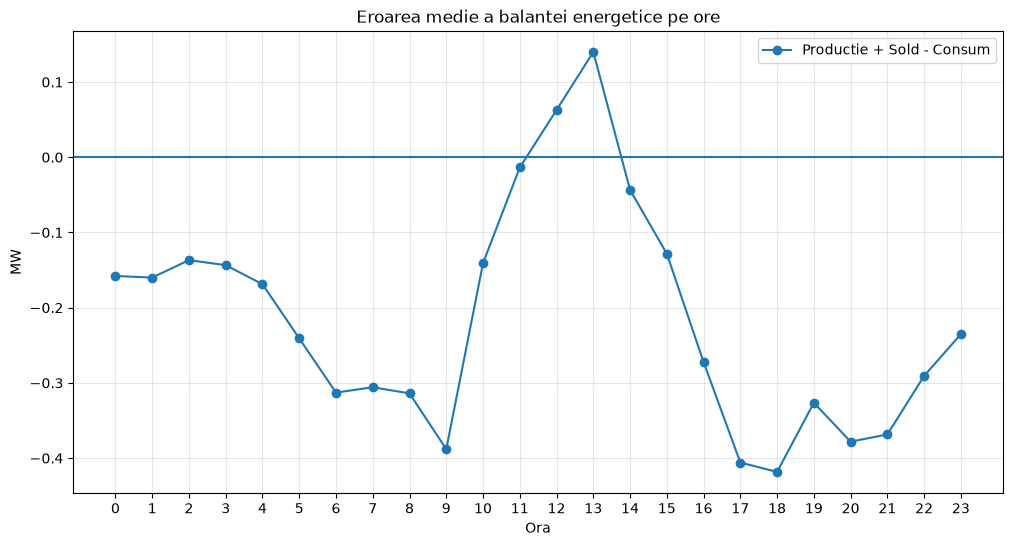

In [ ]:
# Q4 - Cat de bine "prinde" productia totala consumul?
# Exista decalaje sistematice de subproductie / supraproductie?

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Diferenta dintre productie si consum

# Diferenta > 0  -> productia este peste consum
# Diferenta < 0  -> productia este sub consum
df["DiferentaProductieConsum[MW]"] = (
    df["Productie[MW]"]
    - df["Consum[MW]"]
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Verificarea balantei energetice

# Sold > 0 -> import
# Sold < 0 -> export
#
# In mod normal:
# Productie + Sold ≈ Consum

df["EroareBalanta[MW]"] = (
    df["Productie[MW]"]
    + df["Sold[MW]"]
    - df["Consum[MW]"]
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Profilul mediu pe fiecare ora a zilei

hourly_balance = df.groupby("Ora")[
    [
        "Productie[MW]",
        "Consum[MW]",
        "Sold[MW]",
        "DiferentaProductieConsum[MW]",
        "EroareBalanta[MW]"
    ]
].mean()


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Indicatorii generali pentru 2025

mean_difference = (
    df["DiferentaProductieConsum[MW]"].mean()
)

median_difference = (
    df["DiferentaProductieConsum[MW]"].median()
)

# Procentul observatiilor in care productia este sub consum
deficit_share = (
    (df["DiferentaProductieConsum[MW]"] < 0).mean()
    * 100
)

# Procentul observatiilor in care productia este peste consum
surplus_share = (
    (df["DiferentaProductieConsum[MW]"] > 0).mean()
    * 100
)

mean_sold = (
    df["Sold[MW]"].mean()
)

# Cat de mult se abate in medie relatia:
# Productie + Sold = Consum
mean_abs_balance_error = (
    df["EroareBalanta[MW]"].abs().mean()
)

mean_consumption = df["Consum[MW]"].mean()

balance_error_share = (
    mean_abs_balance_error
    / mean_consumption
    * 100
)


print(
    f"Diferenta medie productie - consum: "
    f"{mean_difference:.0f} MW"
)

print(
    f"Diferenta mediana productie - consum: "
    f"{median_difference:.0f} MW"
)

print(
    f"Observatii cu productie sub consum: "
    f"{deficit_share:.1f}%"
)

print(
    f"Observatii cu productie peste consum: "
    f"{surplus_share:.1f}%"
)

print(
    f"Sold mediu: "
    f"{mean_sold:.0f} MW"
)

print(
    f"Eroare medie absoluta a balantei: "
    f"{mean_abs_balance_error:.2f} MW "
    f"({balance_error_share:.3f}% din consumul mediu)"
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Momente relevante ale profilului zilnic

# Ora cu cel mai mare deficit mediu de productie
max_avg_deficit_hour = (
    hourly_balance["DiferentaProductieConsum[MW]"].idxmin()
)

max_avg_deficit_value = (
    hourly_balance["DiferentaProductieConsum[MW]"].min()
)

# Ora cu cel mai mare surplus mediu de productie
max_avg_surplus_hour = (
    hourly_balance["DiferentaProductieConsum[MW]"].idxmax()
)

max_avg_surplus_value = (
    hourly_balance["DiferentaProductieConsum[MW]"].max()
)


print()

print(
    f"Cel mai mare deficit mediu apare in jurul orei "
    f"{max_avg_deficit_hour}: "
    f"{max_avg_deficit_value:.0f} MW"
)

print(
    f"Cel mai mare surplus mediu apare in jurul orei "
    f"{max_avg_surplus_hour}: "
    f"{max_avg_surplus_value:.0f} MW"
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Cele mai mari dezechilibre individuale observate in 2025

largest_deficits = df.nsmallest(
    10,
    "DiferentaProductieConsum[MW]"
)

largest_surpluses = df.nlargest(
    10,
    "DiferentaProductieConsum[MW]"
)


print()

print("Top 10 momente cu productie sub consum:")

print(
    largest_deficits[
        [
            "Data",
            "Productie[MW]",
            "Consum[MW]",
            "DiferentaProductieConsum[MW]",
            "Sold[MW]"
        ]
    ]
)


print()

print("Top 10 momente cu productie peste consum:")

print(
    largest_surpluses[
        [
            "Data",
            "Productie[MW]",
            "Consum[MW]",
            "DiferentaProductieConsum[MW]",
            "Sold[MW]"
        ]
    ]
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Grafic 1 - Productie vs consum pe parcursul zilei

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_balance.index,
    hourly_balance["Consum[MW]"],
    marker="o",
    label="Consum mediu"
)

plt.plot(
    hourly_balance.index,
    hourly_balance["Productie[MW]"],
    marker="o",
    label="Productie medie"
)

plt.xlabel("Ora")
plt.ylabel("MW")

plt.title(
    "Profil mediu zilnic al productiei si consumului"
)

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Grafic 2 - Diferenta medie productie - consum

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_balance.index,
    hourly_balance["DiferentaProductieConsum[MW]"],
    marker="o",
    label="Productie - Consum"
)

plt.axhline(0)

plt.xlabel("Ora")
plt.ylabel("MW")

plt.title(
    "Diferenta medie dintre productie si consum pe ore"
)

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Grafic 3 - Verificarea balantei energetice

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_balance.index,
    hourly_balance["EroareBalanta[MW]"],
    marker="o",
    label="Productie + Sold - Consum"
)

plt.axhline(0)

plt.xlabel("Ora")
plt.ylabel("MW")

plt.title(
    "Eroarea medie a balantei energetice pe ore"
)

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()